## Importing Libraries

In [209]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB
from typing import Literal

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

std = StandardScaler()

## Helper Functions

In [210]:
def load_diabetes_ds():
    df = pd.read_csv('diabetes.csv')

    # Splitting data frame into appropriate features
    x = df.drop(columns=['Outcome']).values
    y = df['Outcome'].values

    return x, y

In [211]:
def load_cancer_ds():
    breast_cancer_ds = load_breast_cancer()

    x = breast_cancer_ds.data
    y = breast_cancer_ds.target
    class_names = list(breast_cancer_ds.target_names)

    return x, y, class_names

In [212]:
def scale_data(X_train, X_test, std):
    """"
    Performs scaling and standardization
    """

    X_train_std = std.fit_transform(X_train)
    X_test_std = std.fit_transform(X_test)

    return X_train_std, X_test_std

In [213]:
def compute_loss_acc(train_X, train_Y, test_X, test_Y, n=200, C=1.0, step=1):
    """
    Training a linear regression model with gradient descent
    """
    model = LogisticRegression(warm_start=True, max_iter=step, C=C)

    # initializing variables
    train_losses = []
    test_losses = []
    test_accs = []
    iters = []

    total = 0
    epsilon = 1e-15

    # Calculating losses and accuracy
    for i in range(0, n, step):
        model.fit(train_X, train_Y) # Built-in training function that replaces the standard training loop
        total += step

        # Manually calculating cross-entropy loss
        train_prob = model.predict_proba(train_X)[:, 1]
        train_prob = np.clip(train_prob, epsilon, (1 - epsilon))

        test_prob = model.predict_proba(test_X)[:, 1]
        test_prob = np.clip(test_prob, epsilon, (1 - epsilon))

        train_loss = -np.mean(train_Y * np.log(train_prob) + (1 - train_Y) * np.log(1 - train_prob))
        test_loss = -np.mean(test_Y * np.log(test_prob) + (1 - test_Y) * np.log(1 - test_prob))

        # Calculating accuracy scores
        test_acc = accuracy_score(test_Y, model.predict(test_X))

        iters.append(total)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        test_accs.append(test_acc)

    return iters, train_losses, test_losses, test_accs, model

In [214]:
def result_metrics(model, test_X, test_Y, average: Literal['binary']='binary'):
    pred_Y = model.predict(test_X)

    metrics = {
        "accuracy": accuracy_score(test_Y, pred_Y),
        "precision": precision_score(test_Y, pred_Y, average=average),
        "recall": recall_score(test_Y, pred_Y, average=average),
        "f1": f1_score(test_Y, pred_Y, average=average)
    }

    return metrics, pred_Y

In [215]:
def print_metrics(metrics, title):
    print(f"========== {title} ==========")
    for k, v in metrics.items():
        print(f"{k.capitalize():<10}: {v:.4f}")
    print()

In [216]:
def _cm(true, pred):
    return confusion_matrix(true, pred)

## Plotting Functions

In [217]:
def plot_loss(train_loss, test_loss, title):
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(test_loss,   label='Testing Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Model Loss')

    plt.title(f'{title}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [218]:
def plot_acc(test_acc, title):
    plt.figure(figsize=(8, 4))
    plt.plot(test_acc,   label='Testing Accuracy')
    plt.xlabel('Iteration')
    plt.ylabel('Model Accuracy')

    plt.title(f'{title}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [219]:
def plot_cm(test_Y, pred_Y, class_names, title="Confusion Matrix"):
    cm = _cm(test_Y, pred_Y)
 
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=class_names, yticklabels=class_names)

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    
    plt.tight_layout()
    plt.show()


## Sub-Functions

In [220]:
def prob1():    
    x, y = load_diabetes_ds()

    # Splitting and standardising the dataset
    train_X_raw, test_X_raw, train_Y, test_Y = train_test_split(x, y, test_size=0.2, random_state=42, stratify=np.asarray(y))
    train_X, test_X = scale_data(train_X_raw, test_X_raw, StandardScaler())
    
    print("=" * 60)
    print("PROBLEM 1: Diabetes Dataset Trained with Logistic Regression")
    print("=" * 60)

    # Training the model
    iters, train_losses, test_losses, test_accs, model = compute_loss_acc(train_X, train_Y, test_X, test_Y, 100, 1.0, 2)

    # Plotting training and validation loss curves
    plot_loss(train_losses, test_losses, title=f'Evaluation Curves of Diabetes Identification Model Trained using Logistic Regression')

    # Plotting accuracies of trained model
    plot_acc(test_accs, title=f"Testing Accuracy of Diabetes Identification Model Trained using Logistic Regression")
    
    # Calculating metrics of resultant model
    metrics, predicted_Y = result_metrics(model, test_X, test_Y)
    print_metrics(metrics, title=f'Metrics of Diabetes Identification Model Trained using Logistic Regression')

    # Plotting the confusion matrix for the trained model
    class_names = ['No Diabetes', 'Diabetes']
    
    plot_cm(test_Y, predicted_Y, class_names, title=f'Confusion Matrix of Diabetes Identification Model Trained using Logistic Regression')

In [221]:
def prob2():
    x, y, class_names = load_cancer_ds()

    # Splitting and standardising the data
    train_X_raw, test_X_raw, train_Y, test_Y = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
    train_X, test_X = scale_data(train_X_raw, test_X_raw, StandardScaler())

    print("=" * 60)
    print("PROBLEM 2: Cancer Dataset Trained with Logistic Regression")
    print("=" * 60)

    print(f'========== Part A: Baseline Training (Weak Penalty) ==========')
    model_baseline = LogisticRegression(C=1e6, max_iter=500)
    model_baseline.fit(train_X, train_Y)
    
    # Printing model metrics after training
    metrics_b, predicted_Y_b = result_metrics(model_baseline, test_X, test_Y)
    print_metrics(metrics_b, title=f'Metrics of Breast Cancer Identification Model Trained using Logistic Regression (No Penalty)')

    # Plotting the confusion matrix
    plot_cm(test_Y, predicted_Y_b, class_names, title=f'Confusion Matrix of Breast Cancer Identification Model Trained using Logistic Regression (No Penalty)')

    print(f'========== Part B: Penalty Training (L2 Penalty) ==========')
    model_l2 = LogisticRegression(C=1e-2, max_iter=500)
    model_l2.fit(train_X, train_Y)

    metrics_l2, predicted_Y_l2 = result_metrics(model_l2, test_X, test_Y)
    print_metrics(metrics_l2, title=f'Metrics of Breast Cancer Identification Model Trained using Logistic Regression (L2 Penalty)')

    # Plotting the confusion matrix
    plot_cm(test_Y, predicted_Y_l2, class_names, title=f'Confusion Matrix of Breast Cancer Identification Model Trained using Logistic Regression (L2 Penalty)')

    return metrics_l2

In [222]:
def prob3():
    x, y, class_names = load_cancer_ds()

    train_X_raw, test_X_raw, train_Y, test_Y = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
    train_X , test_X = scale_data(train_X_raw, test_X_raw, StandardScaler())

    print("=" * 60)
    print("PROBLEM 3: Cancer Dataset Trained with Naive Bayes Classifier")
    print("=" * 60)

    model_nb = GaussianNB()
    model_nb.fit(train_X, train_Y)

    # Printing model metrics after training
    metrics_nb, predicted_Y_nb = result_metrics(model_nb, test_X, test_Y)
    print_metrics(metrics_nb, title=f'Metrics of Breast Cancer Identification Model Trained using Naive Bayes')

    # Plotting the confusion matrics
    plot_cm(test_Y, predicted_Y_nb, class_names, title=f'Confusion Matrix of Breast Cancer Identification Model Trained using Naive Bayes')

    return metrics_nb

In [223]:
def naive_logistic_comp(metrics_logreg, metrics_nb):
    print("=" * 60)
    print("Comparing Model Trained with Naive Bayes vs. Logistic Regression")
    print("=" * 60)

    for k in metrics_logreg:
        print(f"{k.capitalize():<10}:  Logistic Regression={metrics_logreg[k]:.4f}  Naive Bayes={metrics_nb[k]:.4f}")

## Main Function

PROBLEM 1: Diabetes Dataset Trained with Logistic Regression


/home/govind/Documents/introToML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/govind/Documents/introToML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

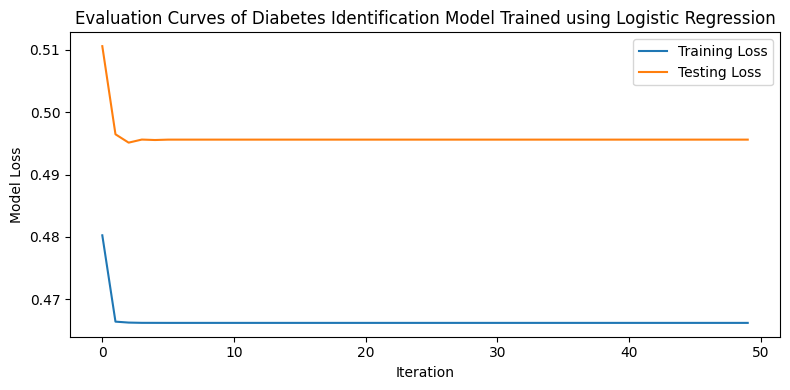

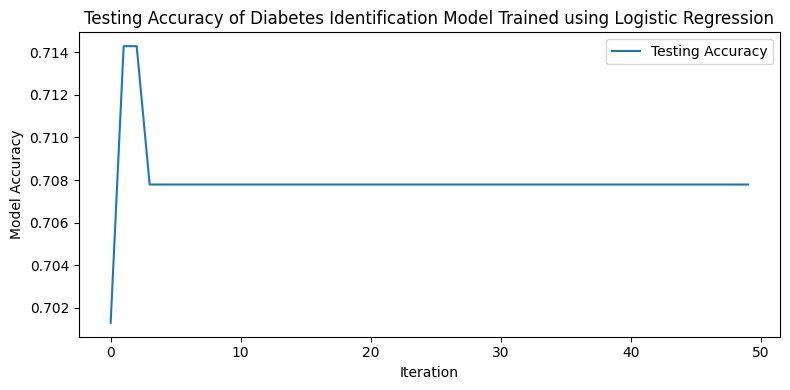

========== Metrics of Diabetes Identification Model Trained using Logistic Regression ==========
Accuracy  : 0.7078
Precision : 0.6000
Recall    : 0.5000
F1        : 0.5455



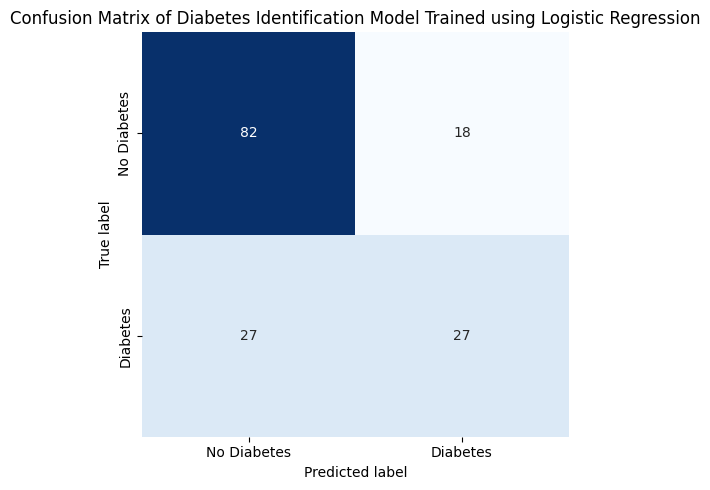

PROBLEM 2: Cancer Dataset Trained with Logistic Regression
========== Part A: Baseline Training (Weak Penalty) ==========
========== Metrics of Breast Cancer Identification Model Trained using Logistic Regression (No Penalty) ==========
Accuracy  : 0.9386
Precision : 0.9710
Recall    : 0.9306
F1        : 0.9504



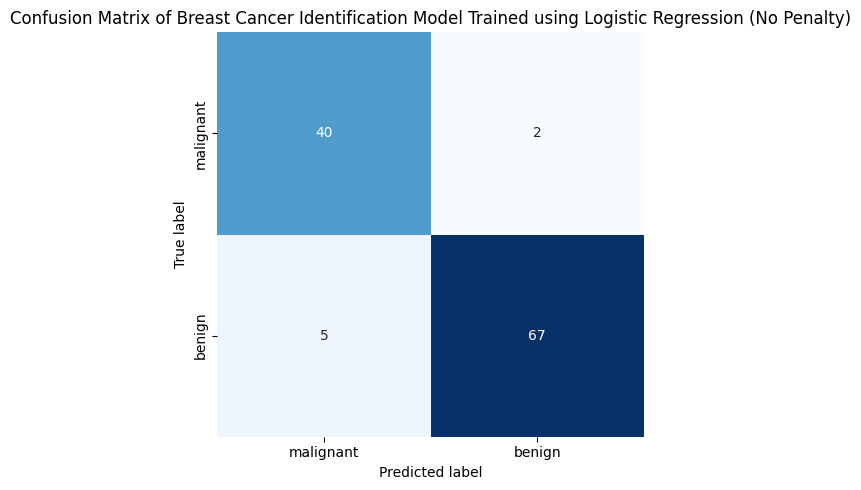

========== Part B: Penalty Training (L2 Penalty) ==========
========== Metrics of Breast Cancer Identification Model Trained using Logistic Regression (L2 Penalty) ==========
Accuracy  : 0.9561
Precision : 0.9351
Recall    : 1.0000
F1        : 0.9664



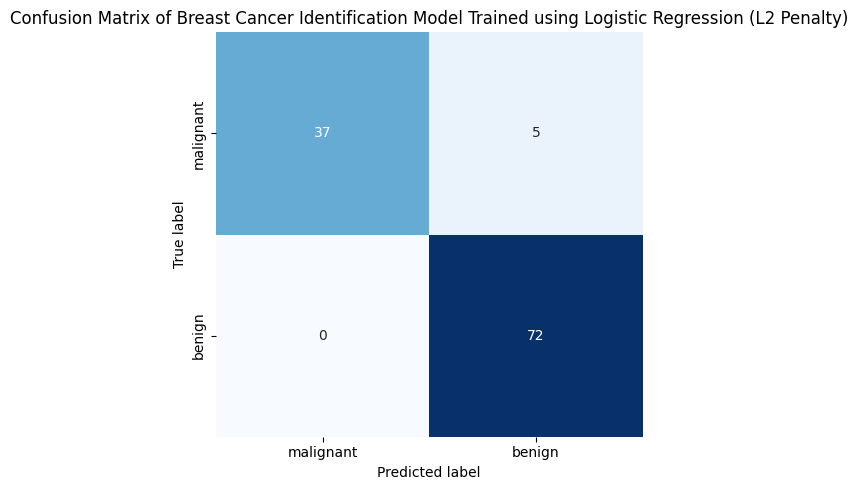

PROBLEM 3: Cancer Dataset Trained with Naive Bayes Classifier
========== Metrics of Breast Cancer Identification Model Trained using Naive Bayes ==========
Accuracy  : 0.9474
Precision : 0.9459
Recall    : 0.9722
F1        : 0.9589



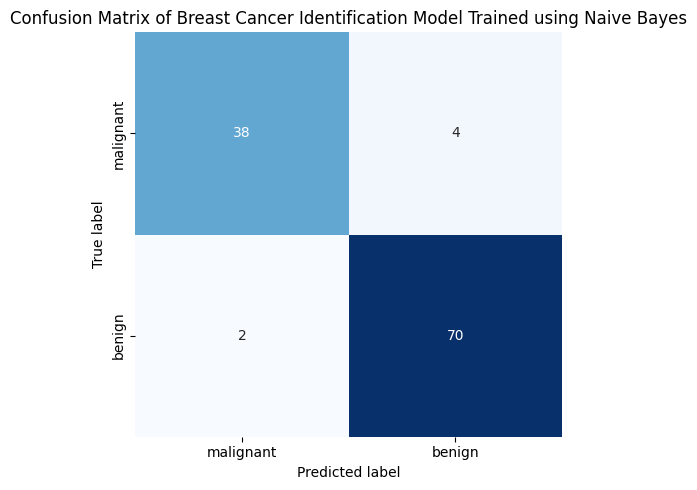

Comparing Model Trained with Naive Bayes vs. Logistic Regression
Accuracy  :  Logistic Regression=0.9561  Naive Bayes=0.9474
Precision :  Logistic Regression=0.9351  Naive Bayes=0.9459
Recall    :  Logistic Regression=1.0000  Naive Bayes=0.9722
F1        :  Logistic Regression=0.9664  Naive Bayes=0.9589


In [224]:
def main():
    prob1()

    metric_p2 = prob2()
    metric_p3 = prob3()

    naive_logistic_comp(metric_p2, metric_p3)

if __name__ == "__main__":
    main()